# CFM Signature Lab — banc d'essai complet

Ce notebook lance **tout** dans l'ordre. Chaque étape lourde est cachée sur disque : si la session s'arrête,
relancer le notebook reprend là où il s'était arrêté.

| § | Étape | Ce qu'on décide |
|---|---|---|
| 0 | Tests logiciels (synthétique) | Le code est-il sain avant de dépenser du GPU ? |
| 1 | Préparation + audit des unités | Tick, lots, catégories inconnues, sens du stress |
| 2 | Screening des features | Quels blocs garder (règle écrite **avant** de regarder) |
| 3 | Modèles tabulaires | XGBoost, LightGBM, MLP sur les blocs retenus |
| 4 | Banc neuronal | 5 variantes, **une seule différence** à chaque fois |
| 5 | Seeds des finalistes | Dispersion avant de conclure |
| 6 | Blend + soumission | Moyenne des finalistes, refit sur tous les labels |
| 7 | Audit | Une seule fois, décisions gelées (désactivé par défaut) |

Partitions : `fit` entraîne, `valid` sélectionne, `stress` = queue de profondeur orientée vers le test (diagnostic),
`audit` scellé. Aucun résultat synthétique (`DEMO=True`) n'a de valeur de performance.

In [1]:
import os, sys, json, subprocess
from pathlib import Path
if sys.platform == 'darwin':
    os.environ.setdefault('OMP_NUM_THREADS', '1')   # macOS : xgboost + torch dans un même processus

def find_repo():
    for p in [Path('.'), Path('..'), Path('/kaggle/working/cfm-signature-lab')]:
        if (p / 'cfm' / '__init__.py').exists():
            return p.resolve()
    for p in Path('/kaggle/input').glob('**/cfm/__init__.py'):
        return p.parent.parent
    raise FileNotFoundError('Dossier du repo introuvable : attacher le Dataset contenant cfm/')

REPO = find_repo(); sys.path.insert(0, str(REPO))

DEMO = True        # True : données synthétiques + CPU, ~2 min. Vérifie le logiciel, jamais la performance.
RUN_TESTS = True    # § 0 : ~3-4 min CPU
SEEDS_SCREEN = [0]  # seed des comparaisons
SEEDS_FINAL = [1]   # seeds supplémentaires pour les finalistes
N_FINALISTS = 2

from cfm import config, io, registry, split, screen, blend, plots   # pas d'xgboost/lightgbm dans ce processus
from cfm.__main__ import prepare
from cfm.neural.train import fit, refit
import pandas as pd
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)

LAB = 'demo_lab' if DEMO else '/kaggle/working/lab'
DEMO_SET = ['neural.d_model=32', 'neural.heads=2', 'neural.train.epochs=4', 'neural.train.patience=4',
            'neural.train.batch_size=64', 'neural.train.amp=false'] if DEMO else []

def load_cfg(name='base', extra=()):
    over = [f'lab_dir={LAB}'] + (['device=cpu'] + DEMO_SET if DEMO else []) + list(extra)
    return config.load(REPO / 'configs' / f'{name}.json', over)

cfg = load_cfg()
if DEMO:
    cfg['screen']['fit_frac'] = 1.0

def cli(*args, name='base'):
    # `python -m cfm ...` in a separate process. Tree models (XGBoost/LightGBM) always run this way:
    # mixing their OpenMP runtime with torch in one process can crash (observed on macOS).
    over = [f'lab_dir={LAB}'] + (['device=cpu', 'screen.fit_frac=1.0'] + DEMO_SET if DEMO else [])
    over += [f'screen.seeds={json.dumps(SEEDS_SCREEN)}']
    cmd = [sys.executable, '-u', '-m', 'cfm', *map(str, args), '--config', str(REPO / 'configs' / f'{name}.json')]
    cmd += sum([['--set', o] for o in over], [])
    p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True,
                         env={**os.environ, 'PYTHONPATH': str(REPO)})
    lines = []
    for line in p.stdout:
        lines.append(line)
        if not line.startswith('[block'):
            print(line, end='')
    if p.wait():
        raise RuntimeError(''.join(lines[-30:]))
print('repo', REPO, '| lab', LAB, '| device', cfg['device'])

repo /private/tmp/claude-501/-Users-thomasdeportzamparc-Library-Application-Support-Claude-scratch-workspaces-2ffe0995-20c8-4066-b284-de6f57a7c444-9fd777de-51e4-48da-ba46-4c974c213e34-scratch-2026-10-06-a69620/76210898-dd47-4214-b247-804f79fda534/scratchpad/nbrun2/repo | lab demo_lab | device cpu


## 0. Tests logiciels
Alignement labels/`obs_id`, fenêtres contiguës, invariance au renumérotage des ordres, unités en ticks, cache, split, reprise, soumission.

In [2]:
if RUN_TESTS:
    out = subprocess.run([sys.executable, str(REPO / 'tests' / 'test_lab.py')], capture_output=True, text=True,
                         env={**os.environ, 'OMP_NUM_THREADS': '1'})
    print('\n'.join(l for l in out.stdout.splitlines() if l.startswith(('PASS', 'FAIL')) or 'failure' in l))
    assert out.returncode == 0, out.stdout[-3000:] + out.stderr[-3000:]

PASS test_neural_runs_resumes_and_refuses_other_config
PASS test_labels_aligned_with_obs_id
PASS test_rejects_non_contiguous_windows
PASS test_order_rank_keeps_only_equalities
PASS test_order_helpers_match_naive_loop
PASS test_tick_units_on_handcrafted_window
PASS test_relative_blocks_invariant_to_size_scaling_levels_are_not
PASS test_feature_cache_is_keyed_on_context
PASS test_split_disjoint_and_audit_independent_of_stress
PASS test_tabular_end_to_end_and_test_alignment
PASS test_sinkhorn_balances_columns
0 failure(s)


## 1. Préparation et audit des unités

In [3]:
files = None
if DEMO:
    from cfm.synthetic import create
    files = create('demo_data')
sp = prepare(cfg, files)          # sinon : détection auto dans /kaggle/input ; sinon renseigner cfg['files']
meta = io.meta(LAB)
print(json.dumps({k: meta[k] for k in ['tick_report', 'unknown_codes', 'venue_vocab', 'counts']}, indent=2))
print(json.dumps(json.loads((Path(LAB) / 'split.json').read_text()), indent=2))
assert meta['tick_report'].get('grid_ok', True), 'Prix hors grille : les blocs en ticks sont approximatifs, lire EXPERIMENTS.md'
registry.catalogue()

[raw train] 480/480


[raw test] 144/144


tick report: {"tick": 0.01, "top_spreads": {"0.01": 25635, "0.02": 10420, "0.03": 6944, "0.04": 5001}, "price_off_grid": 0.0, "bid_off_grid": 0.0, "ask_off_grid": 0.0, "grid_ok": true}


[block tok_action/train] 1 columns, key 7f8ce42c1c


[block tok_action/test] 1 columns, key 7f8ce42c1c


...

[block transitions/train] 36 columns, key 4d77a2132c


[block transitions/test] 36 columns, key 4d77a2132c


split {'config': {'seed': 42, 'audit': 0.1, 'stress': 0.1, 'valid': 0.15, 'stress_tail': 'auto'}, 'tail_used': 'low', 'sizes': {'fit': 312, 'valid': 72, 'stress': 48, 'audit': 48}, 'transductive': True, 'median_log_depth': {'train': 2.890371799468994, 'test': 2.397895336151123}}


{
  "tick_report": {
    "tick": 0.01,
    "top_spreads": {
      "0.01": 25635,
      "0.02": 10420,
      "0.03": 6944,
      "0.04": 5001
    },
    "price_off_grid": 0.0,
    "bid_off_grid": 0.0,
    "ask_off_grid": 0.0,
    "grid_ok": true
  },
  "unknown_codes": {
    "train": {
      "venue": 0,
      "action": 0,
      "side": 0,
      "trade": 0
    },
    "test": {
      "venue": 0,
      "action": 0,
      "side": 0,
      "trade": 0
    }
  },
  "venue_vocab": [
    "0",
    "1",
    "2",
    "3",
    "4",
    "5"
  ],
  "counts": {
    "train": 480,
    "test": 144
  }
}
{
  "config": {
    "seed": 42,
    "audit": 0.1,
    "stress": 0.1,
    "valid": 0.15,
    "stress_tail": "auto"
  },
  "tail_used": "low",
  "sizes": {
    "fit": 312,
    "valid": 72,
    "stress": 48,
    "audit": 48
  },
  "transductive": true,
  "median_log_depth": {
    "train": 2.890371799468994,
    "test": 2.397895336151123
  }
}


,block,kind,family,doc
0,tok_action,token,token,A/D/U (0 = inconnu).
1,tok_side,token,token,
2,tok_trade,token,token,
3,tok_venue,token,token,"Venue (vocabulaire du train, 0 = inconnue). Ca..."
4,tok_pos,token,token,Distance au meilleur prix de son côté : inconn...
5,tok_size,token,token,"|flux| en lots : nan, 0, odd(<1), 1, (1,2], (2..."
6,tok_spread,token,token,"Spread en ticks : invalide, 0, 1, 2, 3-4, ≥5."
7,tok_dmid,token,token,"Δmid (demi-ticks) : invalide, ≤-1.5, baisse, 0..."
8,tok_occ,token,token,"Occurrence de l'ordre dans la fenêtre : 1re, 2..."
9,tok_prev_action,token,token,Action précédente du même ordre (0 = jamais vu...


## 2. Screening des features
Règle de sélection fixée **avant** de lire les résultats : un bloc est gardé si, ajouté à la base et réentraîné,
la borne basse de l'IC bootstrap de Δ valid est > 0 pour toutes les seeds, et Δ stress ≥ −1 point.
(IC optimiste : les fenêtres d'un même titre-jour ne sont pas indépendantes.)

,block,family,feature,eta2,ks,shift_sd,max_corr_base,nan_share,mode_share
61,levels,level,levels:log_depth_q50,0.980979,0.440171,-0.928282,0.836625,0.0,0.092949
62,levels,level,levels:log_depth_q90,0.976841,0.447115,-0.953185,0.830154,0.0,0.035256
63,levels,level,levels:log_bq_q50,0.945834,0.405983,-0.921547,0.792663,0.0,0.092949
64,levels,level,levels:log_aq_q50,0.942150,0.423077,-0.867207,0.814552,0.0,0.099359
22,cat_freq,category,cat_freq:venue=4,0.928468,0.121795,0.219272,NaN,0.0,0.070513
21,cat_freq,category,cat_freq:venue=3,0.921544,0.060363,0.039871,NaN,0.0,0.067308
24,cat_freq,category,cat_freq:venue=6,0.920407,0.254808,-0.390236,NaN,0.0,0.060897
19,cat_freq,category,cat_freq:venue=1,0.915566,0.118056,0.239808,NaN,0.0,0.076923
20,cat_freq,category,cat_freq:venue=2,0.913451,0.217949,-0.377928,NaN,0.0,0.070513
23,cat_freq,category,cat_freq:venue=5,0.913037,0.129274,0.269655,NaN,0.0,0.073718


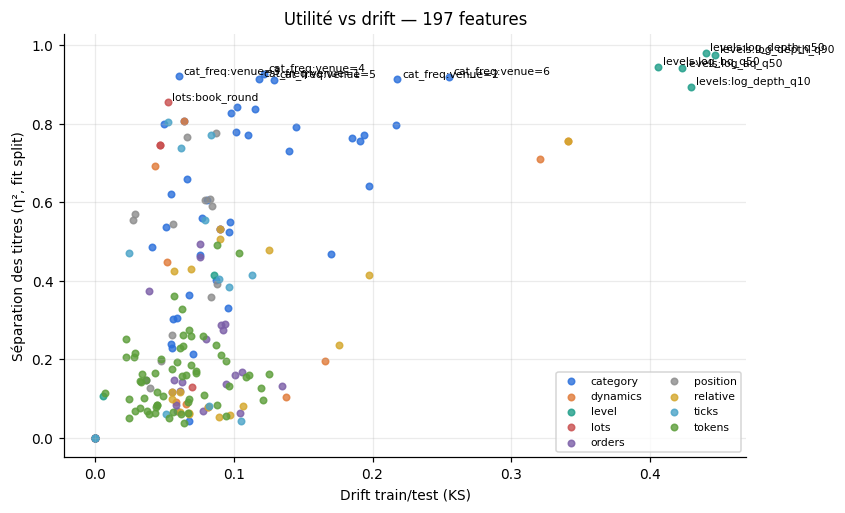

In [4]:
S = cfg['screen']
uni = screen.univariate(LAB, cfg, S['base'] + S['candidates'], base=S['base'])
plots.screen_map(uni, LAB)
uni.head(25)

{'blocks': 'base_relative', 'n_features': 18, 'auc_train_vs_test': 0.6668402777777778}


{'blocks': 'cat_freq', 'n_features': 12, 'auc_train_vs_test': 0.8360243055555555}


{'blocks': 'cat_cross', 'n_features': 30, 'auc_train_vs_test': 0.7861255787037037}


{'blocks': 'levels', 'n_features': 7, 'auc_train_vs_test': 0.8191984953703704}


{'blocks': 'ticks', 'n_features': 14, 'auc_train_vs_test': 0.4757523148148148}


...

{'blocks': 'book_dyn', 'n_features': 10, 'auc_train_vs_test': 0.6338541666666666}


{'blocks': 'tokens_bow', 'n_features': 24, 'auc_train_vs_test': 0.47214988425925924}


{'blocks': 'transitions', 'n_features': 36, 'auc_train_vs_test': 0.453515625}


{'blocks': 'base_relative+cat_freq+cat_cross+levels+ticks+lots+position+orders+book_dyn+tokens_bow+transitions', 'n_features': 197, 'auc_train_vs_test': 0.870558449074074}


,blocks,n_features,auc_train_vs_test
11,base_relative+cat_freq+cat_cross+levels+ticks+...,197,0.870558
1,cat_freq,12,0.836024
3,levels,7,0.819198
2,cat_cross,30,0.786126
0,base_relative,18,0.666840
8,book_dyn,10,0.633854
7,orders,22,0.509852
4,ticks,14,0.475752
9,tokens_bow,24,0.472150
5,lots,9,0.458471


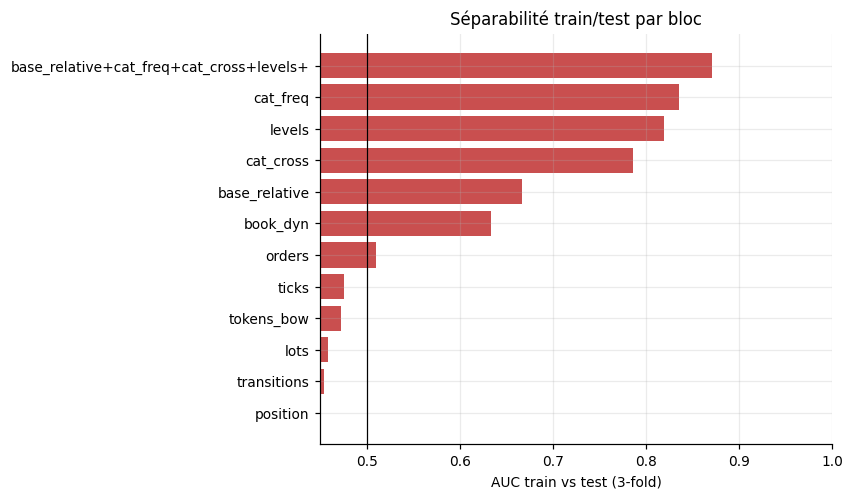

In [5]:
cli('screen', 'adversarial')
adv = pd.read_csv(Path(LAB) / 'screen_adversarial.csv')
plots.adversarial_bars(adv, LAB)
adv.sort_values('auc_train_vs_test', ascending=False)

  +cat_cross      Δvalid -0.0833 [-0.1944,+0.0139]  Δstress +0.0208


  +levels         Δvalid +0.2917 [+0.1944,+0.3892]  Δstress +0.2708


  +ticks          Δvalid -0.0556 [-0.1528,+0.0417]  Δstress +0.0208


  +lots           Δvalid +0.0139 [-0.0972,+0.1250]  Δstress +0.1042


  +position       Δvalid +0.0417 [-0.0556,+0.1389]  Δstress +0.0208


...

  +tokens_bow     Δvalid +0.0000 [-0.0972,+0.0972]  Δstress -0.0417


  +transitions    Δvalid -0.0278 [-0.1389,+0.0833]  Δstress -0.0833


KEEP = ['base_relative', 'cat_freq', 'levels']


/var/folders/3l/s4t1bsn973dfhyz_6q842jr00000gn/T/ipykernel_28095/2007461067.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ok = cand.groupby('candidate').apply(lambda d: (d.d_valid_lo > 0).all() and (d.d_stress_acc >= -0.01).all())


,candidate,seed,iter,n_features,valid_acc,valid_logloss,stress_acc,stress_logloss,d_valid_acc,d_valid_lo,d_valid_hi,d_valid_logloss,d_stress_acc,d_stress_lo,d_stress_hi
2,levels,0,75,37,0.930556,0.492756,0.895833,0.660595,0.291667,0.194444,0.389236,-0.649954,0.270833,0.145313,0.395833
6,orders,0,55,52,0.708333,1.225632,0.645833,1.109064,0.069444,-0.013889,0.152778,0.082922,0.020833,-0.125000,0.145833
5,position,0,61,45,0.680556,1.059752,0.645833,1.023684,0.041667,-0.055556,0.138889,-0.082958,0.020833,-0.104167,0.145833
4,lots,0,104,39,0.652778,1.018814,0.729167,0.796217,0.013889,-0.097222,0.125000,-0.123896,0.104167,0.020833,0.208333
8,tokens_bow,0,83,54,0.638889,1.152482,0.583333,1.078753,0.000000,-0.097222,0.097222,0.009772,-0.041667,-0.145833,0.041667
9,transitions,0,74,66,0.611111,1.200036,0.541667,1.150707,-0.027778,-0.138889,0.083333,0.057326,-0.083333,-0.187500,0.000000
7,book_dyn,0,63,40,0.611111,1.213421,0.645833,1.050595,-0.027778,-0.097222,0.041667,0.070711,0.020833,-0.104167,0.125000
3,ticks,0,57,44,0.583333,1.244874,0.645833,1.149637,-0.055556,-0.152778,0.041667,0.102164,0.020833,-0.062500,0.104687
1,cat_cross,0,90,60,0.555556,1.302602,0.645833,1.105570,-0.083333,-0.194444,0.013889,0.159892,0.020833,-0.083333,0.125000


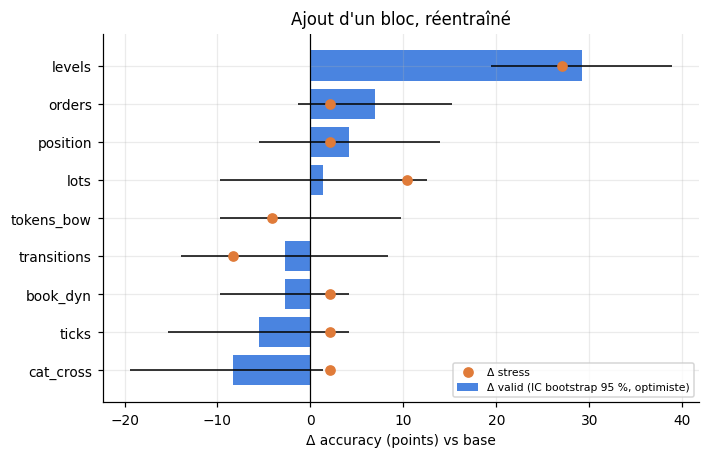

In [6]:
cli('screen', 'forward')
fwd = pd.read_csv(Path(LAB) / 'screen_forward.csv')
plots.forward_bars(fwd, LAB)
cand = fwd[fwd.candidate != '(base)']
ok = cand.groupby('candidate').apply(lambda d: (d.d_valid_lo > 0).all() and (d.d_stress_acc >= -0.01).all())
KEEP = S['base'] + [c for c in S['candidates'] if ok.get(c, False)]
print('KEEP =', KEEP)
cand.sort_values('d_valid_acc', ascending=False)

In [7]:
extra = [b for b in KEEP if b not in S['base']]
if extra:
    cli('screen', 'ablate', '--blocks', *extra)
    abl = pd.read_csv(Path(LAB) / 'screen_ablate.csv')
    display(abl)
else:
    print('Aucun bloc ajouté à la base : pas d’ablation à faire.')

  -base_relative  Δvalid +0.0139 [-0.0278,+0.0694]  Δstress -0.0417


  -cat_freq       Δvalid -0.3750 [-0.4861,-0.2639]  Δstress -0.5000


  -levels         Δvalid -0.2917 [-0.3892,-0.1944]  Δstress -0.2708


,removed,seed,iter,n_features,valid_acc,valid_logloss,stress_acc,stress_logloss,d_valid_acc,d_valid_lo,d_valid_hi,d_stress_acc
0,(none),0,75,37,0.930556,0.492756,0.895833,0.660595,NaN,NaN,NaN,NaN
1,base_relative,0,300,19,0.944444,0.438937,0.854167,0.642116,0.013889,-0.027778,0.069444,-0.041667
2,cat_freq,0,74,25,0.555556,1.318721,0.395833,2.014806,-0.375000,-0.486111,-0.263889,-0.500000
3,levels,0,71,30,0.638889,1.142710,0.625000,1.094331,-0.291667,-0.389236,-0.194444,-0.270833


## 3. Modèles tabulaires sur les blocs retenus

In [8]:
def run_tab(model, name, seed):
    if not (Path(LAB) / 'runs' / name / 'test_refit.npz').exists():
        cli('tabular', '--blocks', *KEEP, '--model', model, '--name', name, '--seed', seed, '--refit', '--note', 'blocs KEEP')
    return json.loads((Path(LAB) / 'runs' / name / 'result.json').read_text())

tab = {f'tab_{m}': run_tab(m, f'tab_{m}', 0) for m in ['xgb', 'lgbm', 'mlp']}
pd.DataFrame(tab.values())[['name', 'n_features', 'best_iter', 'seconds', 'valid_acc', 'valid_logloss', 'stress_acc', 'stress_logloss']]

[tab_xgb] valid 0.9306 / stress 0.8958 (37 features, 1.5s)


[tab_lgbm] valid 0.9583 / stress 0.8750 (37 features, 2.1s)


[tab_mlp] valid 0.9028 / stress 0.8958 (37 features, 3.3s)


,name,n_features,best_iter,seconds,valid_acc,valid_logloss,stress_acc,stress_logloss
0,tab_xgb,37,75,1.5,0.930556,0.492756,0.895833,0.660595
1,tab_lgbm,37,121,2.1,0.958333,0.135063,0.875000,0.471737
2,tab_mlp,37,23,3.3,0.902778,0.295064,0.895833,0.340106


## 4. Banc neuronal — une différence à la fois

| Run | Différence | Question |
|---|---|---|
| `control_gru` | BiGRU + fusion linéaire (proche R2) | référence |
| `signature` | tokens + conv + attention à biais même ordre | l'architecture apporte-t-elle quelque chose à entrée égale ? |
| `signature_no_bias` | β même ordre désactivé | le biais relationnel sert-il ? |
| `signature_robust` | venue dropout, jitter des niveaux, dropout de blocs | réduit-on l'écart valid → stress ? |
| `signature_relative_only` | sans niveaux absolus | les niveaux aident-ils malgré le drift ? |

In [9]:
EXPERIMENTS = ['control_gru', 'signature', 'signature_no_bias', 'signature_robust', 'signature_relative_only']
neural = {}
for exp in EXPERIMENTS:
    for seed in SEEDS_SCREEN:
        name = f'{exp}_s{seed}'
        neural[name] = fit(LAB, load_cfg(exp, [f'neural.train.seed={seed}']), name, note=f'banc § 4 : {exp}')
res = pd.DataFrame(neural.values()).set_index('name')
ref = res.loc[f'signature_s{SEEDS_SCREEN[0]}']
res['Δvalid_vs_signature'] = res.valid_acc - ref.valid_acc
res['Δstress_vs_signature'] = res.stress_acc - ref.stress_acc
res[['encoder', 'params', 'best_epoch', 'epochs_run', 'minutes', 'valid_acc', 'valid_logloss', 'stress_acc',
     'stress_logloss', 'Δvalid_vs_signature', 'Δstress_vs_signature']]

[control_gru_s0] ep 01 loss 3.174 valid 0.0694 stress 0.0625 train(eval) 0.1122 (0.5s)


[control_gru_s0] ep 02 loss 3.116 valid 0.1944 stress 0.1875 train(eval) 0.2372 (0.5s)


[control_gru_s0] ep 03 loss 3.048 valid 0.2639 stress 0.2083 train(eval) 0.3173 (0.8s)


[control_gru_s0] ep 04 loss 3.016 valid 0.3056 stress 0.2083 train(eval) 0.3526 (0.5s)


[control_gru_s0] best epoch 4 valid 0.3056 stress 0.2083 params 34,713


...

[signature_relative_only_s0] ep 02 loss 3.161 valid 0.1250 stress 0.1042 train(eval) 0.1090 (1.1s)


[signature_relative_only_s0] ep 03 loss 3.136 valid 0.1250 stress 0.1250 train(eval) 0.1090 (1.1s)


[signature_relative_only_s0] ep 04 loss 3.124 valid 0.1250 stress 0.1250 train(eval) 0.1090 (1.1s)


[signature_relative_only_s0] best epoch 4 valid 0.1250 stress 0.1250 params 58,877


,encoder,params,best_epoch,epochs_run,minutes,valid_acc,valid_logloss,stress_acc,stress_logloss,Δvalid_vs_signature,Δstress_vs_signature
name,,,,,,,,,,,
control_gru_s0,gru,34713,4,4,0.1,0.305556,3.008303,0.208333,3.020017,0.208333,0.125000
signature_s0,conv_rel,61117,4,4,0.1,0.097222,3.130797,0.083333,3.129456,0.000000,0.000000
signature_no_bias_s0,conv_rel,61113,4,4,0.1,0.097222,3.130797,0.083333,3.129457,0.000000,0.000000
signature_robust_s0,conv_rel,61117,4,4,0.1,0.125000,3.132137,0.104167,3.130000,0.027778,0.020833
signature_relative_only_s0,conv_rel,58877,4,4,0.1,0.125000,3.123191,0.125000,3.118866,0.027778,0.041667


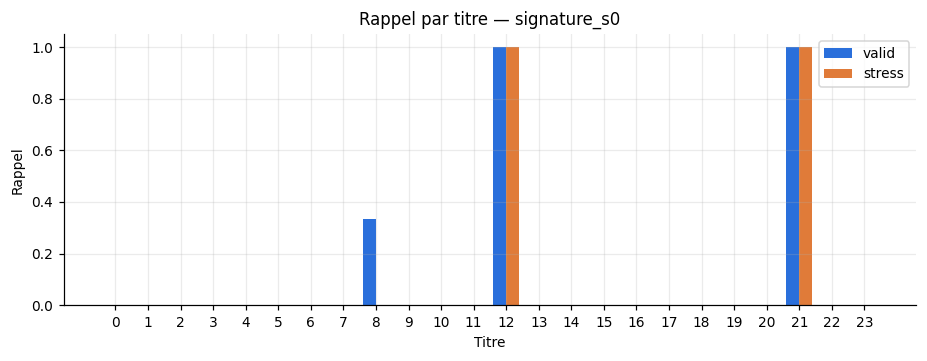

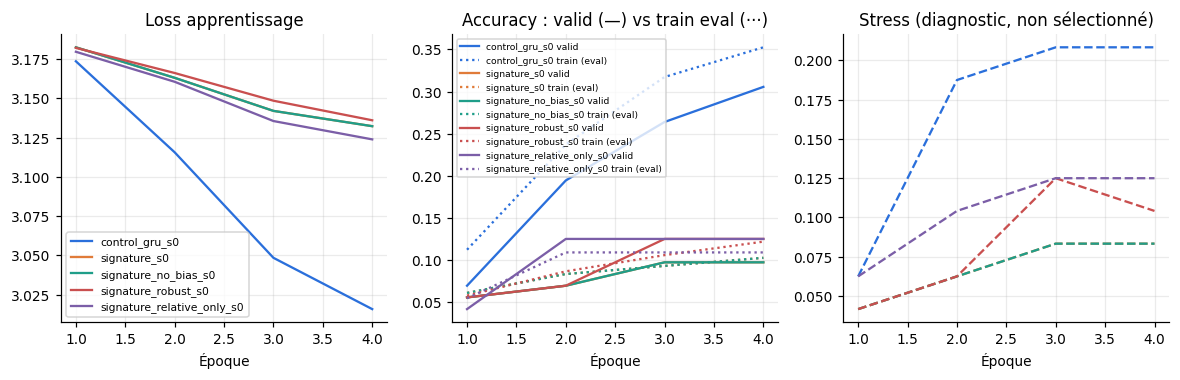

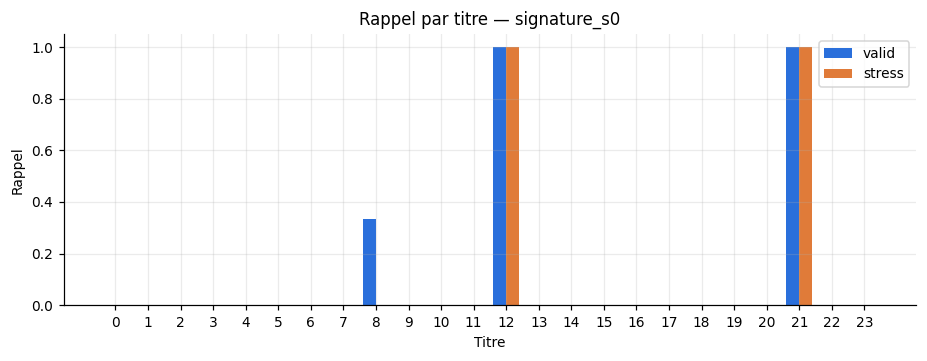

In [10]:
plots.histories(LAB, list(neural))
plots.recall_by_class(LAB, f'signature_s{SEEDS_SCREEN[0]}')

## 5. Finalistes : seeds supplémentaires
Les `N_FINALISTS` meilleurs runs (valid) toutes familles confondues, relancés avec d'autres seeds. On rapporte chaque seed.

In [11]:
allres = pd.concat([pd.DataFrame(tab.values()).set_index('name'), res], sort=False)
finalists = allres.sort_values('valid_acc', ascending=False).index[:N_FINALISTS].tolist()
print('finalistes :', finalists)
seed_rows = []
for f in finalists:
    for seed in SEEDS_FINAL:
        if f.startswith('tab_'):
            r = run_tab(f.split('_')[1], f'{f}_s{seed}', seed)
        else:
            exp = f.rsplit('_s', 1)[0]
            r = fit(LAB, load_cfg(exp, [f'neural.train.seed={seed}']), f'{exp}_s{seed}', note='seed finaliste')
        seed_rows.append({'family': f, 'run': r['name'], 'seed': seed, 'valid_acc': r['valid_acc'], 'stress_acc': r['stress_acc']})
seeds = pd.concat([pd.DataFrame([{'family': f, 'run': f, 'seed': int(allres.loc[f].get('seed', 0) or 0),
                                  'valid_acc': allres.loc[f].valid_acc, 'stress_acc': allres.loc[f].stress_acc} for f in finalists]),
                   pd.DataFrame(seed_rows)])
display(seeds)
seeds.groupby('family')[['valid_acc', 'stress_acc']].agg(['mean', 'std', 'count'])

finalistes : ['tab_lgbm', 'tab_xgb']


[tab_lgbm_s1] valid 0.9583 / stress 0.8542 (37 features, 2.5s)


[tab_xgb_s1] valid 0.9306 / stress 0.9167 (37 features, 1.9s)


,family,run,seed,valid_acc,stress_acc
0,tab_lgbm,tab_lgbm,0,0.958333,0.875000
1,tab_xgb,tab_xgb,0,0.930556,0.895833
0,tab_lgbm,tab_lgbm_s1,1,0.958333,0.854167
1,tab_xgb,tab_xgb_s1,1,0.930556,0.916667


valid_acc            stress_acc                
              mean  std count       mean       std count
family                                                  
tab_lgbm  0.958333  0.0     2   0.864583  0.014731     2
tab_xgb   0.930556  0.0     2   0.906250  0.014731     2

## 6. Blend des finalistes, refit, soumission
Règle : moyenne simple de tous les runs des finalistes (toutes seeds). Pas de poids appris → valid reste un score propre du blend.

oracle (au moins un membre juste sur valid) : 0.9722


,model,valid_acc,valid_logloss,stress_acc,stress_logloss
0,tab_lgbm,0.958333,0.135063,0.875000,0.471737
1,tab_xgb,0.930556,0.492756,0.895833,0.660595
2,tab_lgbm_s1,0.958333,0.137162,0.854167,0.545534
3,tab_xgb_s1,0.930556,0.498742,0.916667,0.645526
4,blend (mean),0.958333,0.284805,0.875000,0.511205
5,blend + balance,0.972222,0.259727,0.937500,0.438914


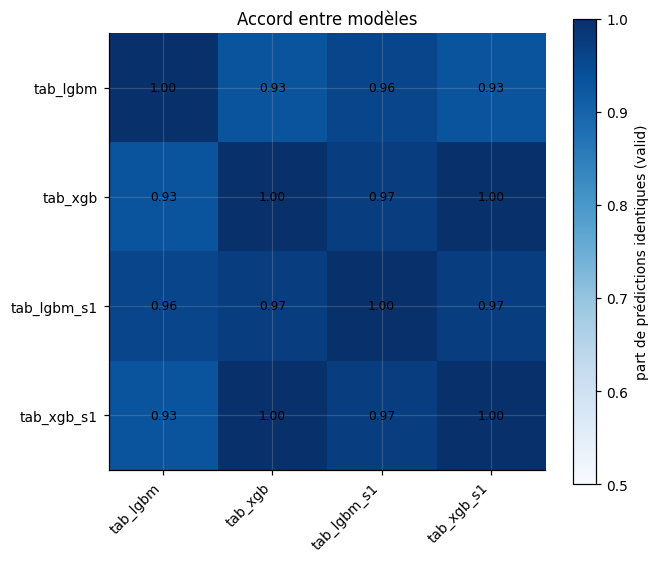

In [12]:
MEMBERS = seeds.run.tolist()
table, w, agree, oracle = blend.report(LAB, MEMBERS, optimise=False)
plots.agreement(agree, LAB)
print('oracle (au moins un membre juste sur valid) :', round(oracle, 4))
table

In [13]:
for m in MEMBERS:
    if not m.startswith('tab_'):                   # les tabulaires ont déjà été refittés
        exp = m.rsplit('_s', 1)[0]; seed = int(m.rsplit('_s', 1)[1])
        refit(LAB, load_cfg(exp, [f'neural.train.seed={seed}']), m, 'epochs')
path = blend.submission(LAB, MEMBERS, None, source='test_refit', balance=False, name='submission_finalists_mean')
print(path); pd.read_csv(path).head()
# Variante transductive, seulement si le règlement l'autorise :
# blend.submission(LAB, MEMBERS, None, source='test_refit', balance=True, name='submission_finalists_balanced')

demo_lab/submission_finalists_mean.csv


,obs_id,eqt_code_cat
0,500000,0
1,500001,10
2,500002,8
3,500003,3
4,500004,10


In [14]:
import zipfile
dest = Path(LAB).parent / ('demo_results.zip' if DEMO else 'lab_results.zip')
with zipfile.ZipFile(dest, 'w', zipfile.ZIP_DEFLATED) as z:
    for p in Path(LAB).rglob('*'):
        if p.is_file() and not {'raw', 'features'} & set(p.relative_to(LAB).parts) and p.suffix != '.pt':
            z.write(p, p.relative_to(LAB))
print(dest, round(dest.stat().st_size / 1e6, 1), 'Mo — ledger, configs, probabilités, figures, soumissions')
pd.read_csv(Path(LAB) / 'ledger.csv').tail(15)

demo_results.zip 0.8 Mo — ledger, configs, probabilités, figures, soumissions


,time,name,kind,model,blocks,candidates,seeds,fit_frac,seed,n_features,best_iter,seconds,valid_acc,valid_logloss,stress_acc,...,encoder,best_epoch,best_step,epochs_run,steps_per_epoch,minutes,tokens,event_blocks,context_blocks,config,runs,weights,source,balance,file
0,2026-10-06T12:30:33,screen_forward,screen,xgb,"[""base_relative"", ""cat_freq""]","[""cat_cross"", ""levels"", ""ticks"", ""lots"", ""posi...",[0],1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-10-06T12:30:40,screen_ablate,screen,xgb,"[""base_relative"", ""cat_freq"", ""levels""]",NaN,[0],1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-10-06T12:30:43,tab_xgb,tabular,xgb,"[""base_relative"", ""cat_freq"", ""levels""]",NaN,NaN,NaN,0.0,37.0,75.0,1.5,0.930556,0.492756,0.895833,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-10-06T12:30:47,tab_lgbm,tabular,lgbm,"[""base_relative"", ""cat_freq"", ""levels""]",NaN,NaN,NaN,0.0,37.0,121.0,2.1,0.958333,0.135063,0.875000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-10-06T12:30:53,tab_mlp,tabular,mlp,"[""base_relative"", ""cat_freq"", ""levels""]",NaN,NaN,NaN,0.0,37.0,23.0,3.3,0.902778,0.295064,0.895833,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2026-10-06T12:30:58,control_gru_s0,neural,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.305556,3.008303,0.208333,...,gru,4.0,20.0,4.0,5.0,0.1,"[""tok_action"", ""tok_side"", ""tok_trade"", ""tok_v...","[""ev_relative"", ""ev_levels""]","[""levels"", ""ticks"", ""lots"", ""position"", ""order...","{""tokens"": [""tok_action"", ""tok_side"", ""tok_tra...",NaN,NaN,NaN,NaN,NaN
6,2026-10-06T12:31:05,signature_s0,neural,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.097222,3.130797,0.083333,...,conv_rel,4.0,20.0,4.0,5.0,0.1,"[""tok_action"", ""tok_side"", ""tok_trade"", ""tok_v...","[""ev_relative"", ""ev_levels""]","[""levels"", ""ticks"", ""lots"", ""position"", ""order...","{""tokens"": [""tok_action"", ""tok_side"", ""tok_tra...",NaN,NaN,NaN,NaN,NaN
7,2026-10-06T12:31:11,signature_no_bias_s0,neural,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.097222,3.130797,0.083333,...,conv_rel,4.0,20.0,4.0,5.0,0.1,"[""tok_action"", ""tok_side"", ""tok_trade"", ""tok_v...","[""ev_relative"", ""ev_levels""]","[""levels"", ""ticks"", ""lots"", ""position"", ""order...","{""tokens"": [""tok_action"", ""tok_side"", ""tok_tra...",NaN,NaN,NaN,NaN,NaN
8,2026-10-06T12:31:18,signature_robust_s0,neural,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.125000,3.132137,0.104167,...,conv_rel,4.0,20.0,4.0,5.0,0.1,"[""tok_action"", ""tok_side"", ""tok_trade"", ""tok_v...","[""ev_relative"", ""ev_levels""]","[""levels"", ""ticks"", ""lots"", ""position"", ""order...","{""tokens"": [""tok_action"", ""tok_side"", ""tok_tra...",NaN,NaN,NaN,NaN,NaN
9,2026-10-06T12:31:24,signature_relative_only_s0,neural,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.125000,3.123191,0.125000,...,conv_rel,4.0,20.0,4.0,5.0,0.1,"[""tok_action"", ""tok_side"", ""tok_trade"", ""tok_v...","[""ev_relative""]","[""ticks"", ""position"", ""orders"", ""cat_freq""]","{""tokens"": [""tok_action"", ""tok_side"", ""tok_tra...",NaN,NaN,NaN,NaN,NaN


## 7. Audit — une seule fois
À décommenter seulement quand blocs, modèles, seeds, budget de refit et règle de blend sont figés.

In [15]:
# from cfm.audit import open_audit
# open_audit(LAB, MEMBERS, confirm=True)